In [1]:
import pandas as pd

dataset = pd.read_csv('merged_dataset.csv')

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  10624 non-null  int64  
 1   data                            10624 non-null  str    
 2   rodada                          8452 non-null   float64
 3   estadio                         8441 non-null   str    
 4   arbitro                         6742 non-null   str    
 5   publico                         6742 non-null   float64
 6   publico_max                     4180 non-null   float64
 7   time_mandante                   10624 non-null  int64  
 8   time_visitante                  10624 non-null  int64  
 9   tecnico_mandante                6299 non-null   str    
 10  tecnico_visitante               6299 non-null   str    
 11  colocacao_mandante              6742 non-null   float64
 12  colocacao_visitante             6742 non-nu

# Preenchendo estatísticas NaN (exceto odd)

## Gols Pro, gols contra, saldos de gol, vitórias, empates, derrotas

In [2]:
# Garante que a coluna 'data' está no formato de data e ordena o dataset
dataset['data'] = pd.to_datetime(dataset['data'])
dataset = dataset.sort_values(by=['ano_campeonato', 'data', 'rodada']).reset_index(drop=True)

# Colunas a serem criadas para mandantes e visitantes
stats_cols = [
    'gols_pro', 'gols_sofridos', 'saldo_gols',
    'vitorias', 'empates', 'derrotas'
]
for col in stats_cols:
    dataset[f'{col}_mandante'] = 0
    dataset[f'{col}_visitante'] = 0

# Itera sobre cada temporada
for ano in dataset['ano_campeonato'].unique():
    # Dicionário para armazenar as estatísticas de cada time na temporada
    stats_temporada = {}
    
    # Filtra o dataset para a temporada atual
    df_temporada = dataset[dataset['ano_campeonato'] == ano]

    for index, row in df_temporada.iterrows():
        time_mandante = row['time_mandante']
        time_visitante = row['time_visitante']
        gols_mandante = row['gols_mandante']
        gols_visitante = row['gols_visitante']

        # Inicializa as estatísticas para times novos na temporada
        for time in [time_mandante, time_visitante]:
            if time not in stats_temporada:
                stats_temporada[time] = {col: 0 for col in stats_cols}

        # Atribui as estatísticas acumuladas *antes* do jogo atual
        for col in stats_cols:
            dataset.loc[index, f'{col}_mandante'] = stats_temporada[time_mandante][col]
            dataset.loc[index, f'{col}_visitante'] = stats_temporada[time_visitante][col]

        # Atualiza as estatísticas do time mandante após o jogo
        stats_temporada[time_mandante]['gols_pro'] += gols_mandante
        stats_temporada[time_mandante]['gols_sofridos'] += gols_visitante
        
        # Atualiza as estatísticas do time visitante após o jogo
        stats_temporada[time_visitante]['gols_pro'] += gols_visitante
        stats_temporada[time_visitante]['gols_sofridos'] += gols_mandante

        # Atualiza vitórias, empates e derrotas
        if gols_mandante > gols_visitante:
            stats_temporada[time_mandante]['vitorias'] += 1
            stats_temporada[time_visitante]['derrotas'] += 1
        elif gols_visitante > gols_mandante:
            stats_temporada[time_visitante]['vitorias'] += 1
            stats_temporada[time_mandante]['derrotas'] += 1
        else:
            stats_temporada[time_mandante]['empates'] += 1
            stats_temporada[time_visitante]['empates'] += 1

        # Atualiza o saldo de gols para ambos os times
        stats_temporada[time_mandante]['saldo_gols'] = stats_temporada[time_mandante]['gols_pro'] - stats_temporada[time_mandante]['gols_sofridos']
        stats_temporada[time_visitante]['saldo_gols'] = stats_temporada[time_visitante]['gols_pro'] - stats_temporada[time_visitante]['gols_sofridos']

In [3]:
# Exibe as primeiras linhas com as novas colunas para verificação
dataset[['gols_pro_mandante', 'gols_sofridos_mandante', 'saldo_gols_mandante', 'vitorias_mandante', 'empates_mandante', 'derrotas_mandante', 
         'gols_pro_visitante', 'gols_sofridos_visitante', 'saldo_gols_visitante', 'vitorias_visitante', 'empates_visitante', 'derrotas_visitante']].describe()

,gols_pro_mandante,gols_sofridos_mandante,saldo_gols_mandante,vitorias_mandante,empates_mandante,derrotas_mandante,gols_pro_visitante,gols_sofridos_visitante,saldo_gols_visitante,vitorias_visitante,empates_visitante,derrotas_visitante
count,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000
mean,25.987199,26.246423,-0.259224,7.564006,5.752730,7.684111,26.184206,26.088385,0.095821,7.667075,5.728633,7.618882
std,17.396631,17.520717,11.631643,5.619040,4.134305,5.714915,17.470090,17.559501,11.804331,5.638849,4.101171,5.746994
min,0.000000,0.000000,-82.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-80.000000,0.000000,0.000000,0.000000
25%,12.000000,12.000000,-6.000000,3.000000,2.000000,3.000000,12.000000,12.000000,-6.000000,3.000000,2.000000,3.000000
50%,25.000000,25.000000,0.000000,7.000000,5.000000,7.000000,25.000000,24.000000,0.000000,7.000000,5.000000,7.000000
75%,38.000000,38.000000,5.000000,11.000000,8.000000,11.000000,38.000000,38.000000,6.000000,11.000000,8.000000,11.000000
max,104.000000,110.000000,64.000000,33.000000,23.000000,36.000000,110.000000,108.000000,69.000000,34.000000,23.000000,35.000000


## Rodada

In [4]:
# Ordena o dataset para garantir que os jogos estão em ordem cronológica dentro de cada temporada
dataset = dataset.sort_values(by=['ano_campeonato', 'data', 'rodada']).reset_index(drop=True)

# Itera sobre cada temporada para preencher a coluna 'rodada'
for ano in dataset['ano_campeonato'].unique():
    # Filtra o dataset para a temporada atual
    df_temporada = dataset[dataset['ano_campeonato'] == ano]
    
    # Obtém a lista de todos os times únicos na temporada
    times_na_temporada = pd.concat([df_temporada['time_mandante'], df_temporada['time_visitante']]).unique()
    
    rodada_atual = 1
    times_jogaram_na_rodada = set()
    
    # Itera sobre os jogos da temporada em ordem cronológica
    for index, row in df_temporada.iterrows():
        time_mandante = row['time_mandante']
        time_visitante = row['time_visitante']
        
        if pd.notna(df_temporada.loc[index, 'rodada']):
            rodada_atual = df_temporada.loc[index, 'rodada'].astype(int)
            times_jogaram_na_rodada.add(time_mandante)
            times_jogaram_na_rodada.add(time_visitante)
            continue
        # Verifica se os times já jogaram nesta rodada
        elif time_mandante in times_jogaram_na_rodada or time_visitante in times_jogaram_na_rodada:
            # Se um dos times já jogou, significa que uma nova rodada começou
            rodada_atual += 1
            times_jogaram_na_rodada = {time_mandante, time_visitante}
        else:
            # Adiciona os times ao conjunto de times que jogaram na rodada atual
            times_jogaram_na_rodada.add(time_mandante)
            times_jogaram_na_rodada.add(time_visitante)

        dataset.loc[index, 'rodada'] = rodada_atual

# Converte a coluna 'rodada' para inteiro, pois não haverá mais NaNs
dataset['rodada'] = dataset['rodada'].astype(int)

print("Preenchimento da coluna 'rodada' concluído.")
dataset[['ano_campeonato', 'data', 'rodada', 'time_mandante', 'time_visitante']].head(100)

Preenchimento da coluna 'rodada' concluído.


,ano_campeonato,data,rodada,time_mandante,time_visitante
0,2003,2003-03-29,1,5,26
1,2003,2003-03-29,1,27,46
2,2003,2003-03-30,1,13,4
3,2003,2003-03-30,1,15,22
4,2003,2003-03-30,1,16,44
...,...,...,...,...,...
95,2003,2003-05-11,8,35,22
96,2003,2003-05-11,8,46,18
97,2003,2003-05-17,9,22,20
98,2003,2003-05-17,9,31,42


## Colocações a cada rodada (colocação do time na tabela a cada rodada)

In [5]:
import numpy as np 

# Itera sobre cada temporada para calcular as colocações
for ano in dataset.sort_values(by=['ano_campeonato', 'data'])['ano_campeonato'].unique():
    # Filtra o dataset para a temporada atual
    df_temporada = dataset[dataset['ano_campeonato'] == ano].copy()
    
    # Itera sobre cada rodada da temporada
    for rodada in sorted(df_temporada['rodada'].unique()):
        # Pula rodadas com valor NaN
        if pd.isna(rodada):
            continue

        # Filtra os jogos da rodada atual
        jogos_rodada = df_temporada[df_temporada['rodada'] == rodada]
        
        # Para a primeira rodada, a colocação é baseada no valor da equipe
        if rodada == 1:
            times_valores = {}
            for _, row in jogos_rodada.iterrows():
                times_valores[row['time_mandante']] = np.random.randint(1, 100)  # Atribui um valor aleatório para a equipe mandante
                times_valores[row['time_visitante']] = np.random.randint(1, 100)  # Atribui um valor aleatório para a equipe visitante

            # Se não houver valores de equipe, pula para a próxima rodada
            if not times_valores:
                continue

            df_valores = pd.DataFrame(list(times_valores.items()), columns=['time', 'valor_equipe'])
            df_valores = df_valores.sort_values(by='valor_equipe', ascending=False).reset_index(drop=True)
            df_valores['colocacao'] = df_valores.index + 1
            
            mapa_colocacao_rodada_1 = df_valores.set_index('time')['colocacao'].to_dict()

            for index, row in jogos_rodada.iterrows():
                if pd.isna(dataset.loc[index, 'colocacao_mandante']):
                    dataset.loc[index, 'colocacao_mandante'] = mapa_colocacao_rodada_1.get(row['time_mandante'])
                if pd.isna(dataset.loc[index, 'colocacao_visitante']):
                    dataset.loc[index, 'colocacao_visitante'] = mapa_colocacao_rodada_1.get(row['time_visitante'])
            continue

        # Coleta as estatísticas de todos os times antes desta rodada
        stats_antes_rodada = {}
        times_na_temporada = pd.concat([df_temporada['time_mandante'], df_temporada['time_visitante']]).unique()

        for time in times_na_temporada:
            # Encontra a última partida do time antes da rodada atual
            partidas_anteriores = df_temporada[(df_temporada['rodada'] < rodada) & 
                                               ((df_temporada['time_mandante'] == time) | (df_temporada['time_visitante'] == time))]
            
            if not partidas_anteriores.empty:
                # Ordena para garantir que estamos pegando a partida mais recente antes da rodada atual
                ultima_partida = partidas_anteriores.sort_values(by='data', ascending=False).iloc[0]
                
                if ultima_partida['time_mandante'] == time:
                    stats_time = {
                        'vitorias': ultima_partida['vitorias_mandante'],
                        'empates': ultima_partida['empates_mandante'],
                        'saldo_gols': ultima_partida['saldo_gols_mandante'],
                        'gols_pro': ultima_partida['gols_pro_mandante']
                    }
                else: # time visitante
                    stats_time = {
                        'vitorias': ultima_partida['vitorias_visitante'],
                        'empates': ultima_partida['empates_visitante'],
                        'saldo_gols': ultima_partida['saldo_gols_visitante'],
                        'gols_pro': ultima_partida['gols_pro_visitante']
                    }
                stats_antes_rodada[time] = stats_time
            else: # Time não jogou ainda na temporada antes desta rodada
                 stats_antes_rodada[time] = {'vitorias': 0, 'empates': 0, 'saldo_gols': 0, 'gols_pro': 0}

        # Constrói a tabela de classificação
        if not stats_antes_rodada:
            continue
            
        tabela_classificacao = pd.DataFrame.from_dict(stats_antes_rodada, orient='index')
        tabela_classificacao['pontos'] = tabela_classificacao['vitorias'] * 3 + tabela_classificacao['empates']
        
        tabela_classificacao = tabela_classificacao.sort_values(
            by=['pontos', 'vitorias', 'saldo_gols', 'gols_pro'],
            ascending=[False, False, False, False]
        ).reset_index()
        tabela_classificacao['colocacao'] = tabela_classificacao.index + 1
        tabela_classificacao = tabela_classificacao.rename(columns={'index': 'time'})
        
        mapa_colocacao = tabela_classificacao.set_index('time')['colocacao'].to_dict()

        # Atualiza as colocações no dataset principal para os jogos da rodada
        for index, row in jogos_rodada.iterrows():
            if pd.isna(dataset.loc[index, 'colocacao_mandante']):
                dataset.loc[index, 'colocacao_mandante'] = mapa_colocacao.get(row['time_mandante'])
            if pd.isna(dataset.loc[index, 'colocacao_visitante']):
                dataset.loc[index, 'colocacao_visitante'] = mapa_colocacao.get(row['time_visitante'])

print("Preenchimento das colocações concluído.")


Preenchimento das colocações concluído.


In [6]:
dataset[['ano_campeonato', 'rodada', 'time_mandante', 'colocacao_mandante', 'time_visitante', 'colocacao_visitante']].tail(10)

,ano_campeonato,rodada,time_mandante,colocacao_mandante,time_visitante,colocacao_visitante
10614,2026,18,4,11.0,47,18.0
10615,2026,18,22,3.0,45,4.0
10616,2026,18,28,12.0,46,13.0
10617,2026,18,2,5.0,21,2.0
10618,2026,18,8,10.0,13,17.0
10619,2026,18,12,20.0,48,19.0
10620,2026,18,18,6.0,26,14.0
10621,2026,18,33,1.0,16,15.0
10622,2026,18,38,7.0,19,9.0
10623,2026,18,41,16.0,14,8.0


In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         8441 non-null   str           
 4   arbitro                         6742 non-null   str           
 5   publico                         6742 non-null   float64       
 6   publico_max                     4180 non-null   float64       
 7   time_mandante                   10624 non-null  int64         
 8   time_visitante                  10624 non-null  int64         
 9   tecnico_mandante                6299 non-null   str           
 10  tecnico_visitante               6299 non-null   str           
 11  colocacao_man

## Estádio, público e público máximo

In [8]:
# Encontra o estádio mais frequente para cada time mandante
estadio_mais_frequente_por_time = dataset.dropna(subset=['estadio']).groupby('time_mandante')['estadio'].apply(lambda x: x.mode()[0])

# Preenche os valores NaN na coluna 'estadio' usando o mapa criado
# Apenas para as linhas onde 'estadio' é NaN
for index, row in dataset[dataset['estadio'].isna()].iterrows():
    time_mandante = row['time_mandante']
    if time_mandante in estadio_mais_frequente_por_time:
        dataset.loc[index, 'estadio'] = estadio_mais_frequente_por_time[time_mandante]

# Para qualquer time que ainda possa ter NaN (se nunca jogou como mandante com um estádio registrado)
# Preenche com a moda geral de estádios
if dataset['estadio'].isna().any():
    moda_geral_estadio = dataset['estadio'].mode()[0]
    dataset['estadio'] = dataset['estadio'].fillna(moda_geral_estadio)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         10624 non-null  str           
 4   arbitro                         6742 non-null   str           
 5   publico                         6742 non-null   float64       
 6   publico_max                     4180 non-null   float64       
 7   time_mandante                   10624 non-null  int64         
 8   time_visitante                  10624 non-null  int64         
 9   tecnico_mandante                6299 non-null   str           
 10  tecnico_visitante               6299 non-null   str           
 11  colocacao_man

In [9]:

def fillna_media_temporada(dataset, coluna):
    # para cada temporada
    print(f"Preenchendo NaNs para a coluna '{coluna}' por temporada e estádio...")
    for ano in dataset.sort_values(by=['ano_campeonato', 'data'])['ano_campeonato'].unique():
        df_temporada = dataset[dataset['ano_campeonato'] == ano]

        # Calcula a média de público de cada estádio
        for estadio in df_temporada['estadio'].unique():
            media_temporada_estadio = df_temporada[df_temporada['estadio'] == estadio][coluna].mean()
            dataset.loc[(dataset['ano_campeonato'] == ano) & (dataset['estadio'] == estadio) & (dataset[coluna].isna()), coluna] = media_temporada_estadio
    print(f"Preenchimento por temporada e estádio para a coluna '{coluna}' concluído.")

    print(f"Preenchendo NaNs para a coluna '{coluna}' por estádio em todas as temporadas...")
    # Se restarem NaNs, preenche com a média de público por estádio em todas as temporadas
    for estadio in dataset['estadio'].unique():
        media_geral_estadio = dataset[dataset['estadio'] == estadio][coluna].mean()
        dataset.loc[(dataset['estadio'] == estadio) & (dataset[coluna].isna()), coluna] = media_geral_estadio
    print(f"Preenchimento por estádio em todas as temporadas para a coluna '{coluna}' concluído.")

    print(f"Preenchendo NaNs para a coluna '{coluna}' com a média geral de público...")
    # Se ainda houver NaNs (estádios sem nenhum registro de público), preenche com a média geral de público
    media_geral_total = dataset[coluna].mean()
    dataset[coluna] = dataset[coluna].fillna(media_geral_total)
    print(f"Preenchimento com a média geral para a coluna '{coluna}' concluído.")

fillna_media_temporada(dataset, 'publico')
fillna_media_temporada(dataset, 'publico_max')

print(dataset.info())

Preenchendo NaNs para a coluna 'publico' por temporada e estádio...
Preenchimento por temporada e estádio para a coluna 'publico' concluído.
Preenchendo NaNs para a coluna 'publico' por estádio em todas as temporadas...
Preenchimento por estádio em todas as temporadas para a coluna 'publico' concluído.
Preenchendo NaNs para a coluna 'publico' com a média geral de público...
Preenchimento com a média geral para a coluna 'publico' concluído.
Preenchendo NaNs para a coluna 'publico_max' por temporada e estádio...
Preenchimento por temporada e estádio para a coluna 'publico_max' concluído.
Preenchendo NaNs para a coluna 'publico_max' por estádio em todas as temporadas...
Preenchimento por estádio em todas as temporadas para a coluna 'publico_max' concluído.
Preenchendo NaNs para a coluna 'publico_max' com a média geral de público...
Preenchimento com a média geral para a coluna 'publico_max' concluído.
<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 34 

## Valor (R$) de cada time

In [10]:
import numpy as np

# Função para calcular a média ponderada baseada no tempo
def calcular_valor_ponderado(time, data_jogo, df):
    # Encontra todos os jogos anteriores do time onde o valor da equipe é conhecido
    # Evito usar jogos futuros para aproximar o valor presente para evitar vazamento de dados
    jogos_anteriores_mandante = df[(df['time_mandante'] == time) & (df['ano_campeonato'] <= data_jogo) & (df['valor_equipe_titular_mandante'].notna())]
    jogos_anteriores_visitante = df[(df['time_visitante'] == time) & (df['ano_campeonato'] <= data_jogo) & (df['valor_equipe_titular_visitante'].notna())]

    valores = []
    pesos = []

    # Coleta valores e calcula pesos para jogos como mandante
    for _, row in jogos_anteriores_mandante.iterrows():
        delta_tempo = (data_jogo - row['ano_campeonato'])
        valores.append(row['valor_equipe_titular_mandante'])
        if delta_tempo > 0:
            pesos.append(1 / delta_tempo)
        else:
            # Se o jogo for no mesmo ano, atribui um peso alto (por exemplo, 1)
            pesos.append(1)

    # Coleta valores e calcula pesos para jogos como visitante
    for _, row in jogos_anteriores_visitante.iterrows():
        delta_tempo = (data_jogo - row['ano_campeonato'])
        valores.append(row['valor_equipe_titular_visitante'])
        if delta_tempo > 0:
            pesos.append(1 / delta_tempo)
        else:
            # Se o jogo for no mesmo ano, atribui um peso alto (por exemplo, 1)
            pesos.append(1)

    # Se houver valores históricos, calcula a média ponderada
    if pesos:
        return np.average(valores, weights=pesos)
    else:
        # Se não houver histórico, retorna NaN para ser tratado depois
        return np.nan

# Itera sobre as linhas com valores NaN para preenchê-los
for col_valor, col_time in [('valor_equipe_titular_mandante', 'time_mandante'), ('valor_equipe_titular_visitante', 'time_visitante')]:
    # Seleciona as linhas que precisam de preenchimento
    indices_nan = dataset[dataset[col_valor].isna()].index
    
    for index in indices_nan:
        # Pega o time e a data do jogo atual
        time = dataset.loc[index, col_time]
        data_jogo = dataset.loc[index, 'ano_campeonato']
        
        # Calcula o valor ponderado
        valor_calculado = calcular_valor_ponderado(time, data_jogo, dataset)                                                                                                                                                              
        
        # Atribui o valor calculado à célula correspondente
        dataset.loc[index, col_valor] = valor_calculado

# Para os casos restantes (times sem nenhum registro anterior), preenche com a moda do valor das equipes na temporada
if dataset['valor_equipe_titular_mandante'].isna().any() or dataset['valor_equipe_titular_visitante'].isna().any():
    print(f"Valores restantes para preenchimento - Mandante: {dataset['valor_equipe_titular_mandante'].isna().sum()}, Visitante: {dataset['valor_equipe_titular_visitante'].isna().sum()}")

    for ano in dataset['ano_campeonato'].unique():
        if dataset[(dataset['ano_campeonato'] == ano) & (dataset['valor_equipe_titular_mandante'].notna())].empty and \
           dataset[(dataset['ano_campeonato'] == ano) & (dataset['valor_equipe_titular_visitante'].notna())].empty:
            print(f"Temporada {ano} não possui valores conhecidos para ambas as colunas. Pulando esta temporada.")
            continue  # Pula temporadas sem nenhum valor conhecido para ambas as colunas
        
        moda_mandante = dataset[dataset['ano_campeonato'] == ano]['valor_equipe_titular_mandante'].mode()[0]
        moda_visitante = dataset[dataset['ano_campeonato'] == ano]['valor_equipe_titular_visitante'].mode()[0]

        print(f"Preenchendo valores de equipe restantes para a temporada {ano} com a moda: Mandante = {moda_mandante}, Visitante = {moda_visitante}")
        dataset.loc[(dataset['ano_campeonato'] == ano) & (dataset['valor_equipe_titular_mandante'].isna()), 'valor_equipe_titular_mandante'] = moda_mandante
        dataset.loc[(dataset['ano_campeonato'] == ano) & (dataset['valor_equipe_titular_visitante'].isna()), 'valor_equipe_titular_visitante'] = moda_visitante

# Para os casos restantes (se ainda houver), deixa para o imputer lidar  
print(f"Valores restantes para preenchimento após segundo passo - Mandante: {dataset['valor_equipe_titular_mandante'].isna().sum()}, Visitante: {dataset['valor_equipe_titular_visitante'].isna().sum()}")
#moda_geral_mandante = dataset['valor_equipe_titular_mandante'].mode()[0]
#moda_geral_visitante = dataset['valor_equipe_titular_visitante'].mode()[0]
#print(f"Preenchendo valores de equipe restantes com a moda geral: Mandante = {moda_geral_mandante}, Visitante = {moda_geral_visitante}")

#dataset['valor_equipe_titular_mandante'] = dataset['valor_equipe_titular_mandante'].fillna(moda_geral_mandante)
#dataset['valor_equipe_titular_visitante'] = dataset['valor_equipe_titular_visitante'].fillna(moda_geral_visitante)

print("Preenchimento dos valores de equipe concluído.")
dataset.info()

Valores restantes para preenchimento - Mandante: 2143, Visitante: 2144
Temporada 2003 não possui valores conhecidos para ambas as colunas. Pulando esta temporada.
Temporada 2004 não possui valores conhecidos para ambas as colunas. Pulando esta temporada.
Temporada 2005 não possui valores conhecidos para ambas as colunas. Pulando esta temporada.
Temporada 2006 não possui valores conhecidos para ambas as colunas. Pulando esta temporada.
Preenchendo valores de equipe restantes para a temporada 2007 com a moda: Mandante = 500000.0, Visitante = 2700000.0
Preenchendo valores de equipe restantes para a temporada 2008 com a moda: Mandante = 8200000.0, Visitante = 7350000.0
Preenchendo valores de equipe restantes para a temporada 2009 com a moda: Mandante = 28892036.29032258, Visitante = 28779201.970191915
Preenchendo valores de equipe restantes para a temporada 2010 com a moda: Mandante = 8414796.442362597, Visitante = 6200000.0
Preenchendo valores de equipe restantes para a temporada 2011 com

## Idade média do elenco

In [11]:
# Criar uma série com a idade média de cada time, desconsiderando se é mandante ou visitante
idade_mandante = dataset[['time_mandante', 'idade_media_titular_mandante']].rename(columns={'time_mandante': 'time', 'idade_media_titular_mandante': 'idade'})
idade_visitante = dataset[['time_visitante', 'idade_media_titular_visitante']].rename(columns={'time_visitante': 'time', 'idade_media_titular_visitante': 'idade'})

# Concatenar e calcular a média de idade por time
media_idade_por_time = pd.concat([idade_mandante, idade_visitante]).dropna().groupby('time')['idade'].mean()

# Mapear as médias para as colunas de mandante e visitante
dataset['idade_media_titular_mandante'] = dataset['idade_media_titular_mandante'].fillna(dataset['time_mandante'].map(media_idade_por_time))
dataset['idade_media_titular_visitante'] = dataset['idade_media_titular_visitante'].fillna(dataset['time_visitante'].map(media_idade_por_time))

# Para casos onde um time pode não ter nenhum registro de idade (improvável, mas para garantir)
# Preenche com a média geral da coluna
media_geral_idade_mandante = dataset['idade_media_titular_mandante'].mean()
media_geral_idade_visitante = dataset['idade_media_titular_visitante'].mean()

dataset['idade_media_titular_mandante'] = dataset['idade_media_titular_mandante'].fillna(media_geral_idade_mandante)
dataset['idade_media_titular_visitante'] = dataset['idade_media_titular_visitante'].fillna(media_geral_idade_visitante)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         10624 non-null  str           
 4   arbitro                         6742 non-null   str           
 5   publico                         10624 non-null  float64       
 6   publico_max                     10624 non-null  float64       
 7   time_mandante                   10624 non-null  int64         
 8   time_visitante                  10624 non-null  int64         
 9   tecnico_mandante                6299 non-null   str           
 10  tecnico_visitante               6299 non-null   str           
 11  colocacao_man

## Árbitros e técnicos

In [12]:
for ano in dataset['ano_campeonato'].unique():
    # Encontra o árbitro mais frequente (moda) para a temporada atual, ignorando NaNs
    moda_arbitro = dataset[dataset['ano_campeonato'] == ano]['arbitro'].mode()
    
    if not moda_arbitro.empty:
        arbitro_mais_comum = moda_arbitro[0]
        
        # Preenche os NaNs da coluna 'arbitro' para a temporada atual com a moda encontrada
        dataset.loc[(dataset['ano_campeonato'] == ano) & (dataset['arbitro'].isna()), 'arbitro'] = arbitro_mais_comum

# Se ainda houver algum NaN (ex: uma temporada inteira sem dados de árbitro), deixa o imputer lidar
moda_geral_arbitro = dataset['arbitro'].mode()[0]
dataset['arbitro'] = dataset['arbitro'].fillna(moda_geral_arbitro)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         10624 non-null  str           
 4   arbitro                         10624 non-null  str           
 5   publico                         10624 non-null  float64       
 6   publico_max                     10624 non-null  float64       
 7   time_mandante                   10624 non-null  int64         
 8   time_visitante                  10624 non-null  int64         
 9   tecnico_mandante                6299 non-null   str           
 10  tecnico_visitante               6299 non-null   str           
 11  colocacao_man

In [13]:
# Para cada temporada, preenche os NaNs nas colunas de técnicos com a moda do técnico para aquele time na temporada, considerando tanto jogos como mandante quanto visitante
for ano in dataset['ano_campeonato'].unique():

    df_temporada = dataset[dataset['ano_campeonato'] == ano]
    times_temporada = pd.concat([df_temporada['time_mandante'], df_temporada['time_visitante']]).unique()

    for time in times_temporada:
        # Coleta todos os técnicos para um time na temporada, tanto como mandante quanto visitante
        tecnicos_mandante = df_temporada[df_temporada['time_mandante'] == time]['tecnico_mandante']
        tecnicos_visitante = df_temporada[df_temporada['time_visitante'] == time]['tecnico_visitante']
        
        todos_tecnicos = pd.concat([tecnicos_mandante, tecnicos_visitante]).dropna()
        
        if not todos_tecnicos.empty:
            # Encontra o técnico mais frequente (moda)
            moda_tecnico = todos_tecnicos.mode()[0]
            
            # Preenche NaNs para o time como mandante na temporada
            dataset.loc[(dataset['ano_campeonato'] == ano) & (dataset['time_mandante'] == time) & (dataset['tecnico_mandante'].isna()), 'tecnico_mandante'] = moda_tecnico
            
            # Preenche NaNs para o time como visitante na temporada
            dataset.loc[(dataset['ano_campeonato'] == ano) & (dataset['time_visitante'] == time) & (dataset['tecnico_visitante'].isna()), 'tecnico_visitante'] = moda_tecnico

# Para casos onde um time possa não ter nenhum registro de técnico em uma temporada (improvável)
# deixa o imputer lidar
moda_geral_tecnico_mandante = dataset['tecnico_mandante'].mode()[0]
moda_geral_tecnico_visitante = dataset['tecnico_visitante'].mode()[0]

dataset['tecnico_mandante'] = dataset['tecnico_mandante'].fillna(moda_geral_tecnico_mandante)
dataset['tecnico_visitante'] = dataset['tecnico_visitante'].fillna(moda_geral_tecnico_visitante)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         10624 non-null  str           
 4   arbitro                         10624 non-null  str           
 5   publico                         10624 non-null  float64       
 6   publico_max                     10624 non-null  float64       
 7   time_mandante                   10624 non-null  int64         
 8   time_visitante                  10624 non-null  int64         
 9   tecnico_mandante                10624 non-null  str           
 10  tecnico_visitante               10624 non-null  str           
 11  colocacao_man

## Label Encoder

In [14]:
# poderia tirar estadios, arbitro e tecnicos com one hot encoding (pessimo pq adiciona muitas colunas),
#  usar labelencoder(cardinalidade)+embeddings (melhor pq mantém a cardinalidade e não adiciona colunas)
# ou construir uma metrica personalizada EX:
# estadio pode virar uma coluna "joga em casa" binaria, mas essa info ja esta encodada em "time_mandante"
# alem de perder o fit no "clima de bom jogo" que alguns estadios podem ter
# e perder casos especificos em que um mandante nao joga em casa (e pode ser prejudicado)

from sklearn.preprocessing import LabelEncoder

def aplica_label_encoder(coluna):
    label_encoder = LabelEncoder()
    label_encoder.fit(dataset[coluna].dropna())
    conversao = pd.DataFrame({
        coluna: label_encoder.classes_,
        'label_encoded': label_encoder.transform(label_encoder.classes_)
    })
    dataset[coluna] = label_encoder.transform(dataset[coluna])
    
    conversao.to_csv(f'dicts/{coluna}_label_encoder.csv', index=False)

aplica_label_encoder('estadio')
aplica_label_encoder('arbitro')
aplica_label_encoder('tecnico_mandante')
aplica_label_encoder('tecnico_visitante')

dataset.iloc[:, dataset.columns.isin(['estadio', 'arbitro', 'tecnico_mandante', 'tecnico_visitante'])].describe()

,estadio,arbitro,tecnico_mandante,tecnico_visitante
count,10624.000000,10624.000000,10624.000000,10624.000000
mean,40.334808,104.650979,107.484281,105.181852
std,23.989863,57.307756,75.940214,74.430234
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,45.000000,42.000000,41.000000
50%,44.000000,108.000000,87.000000,86.000000
75%,62.000000,162.000000,174.000000,171.000000
max,83.000000,207.000000,258.000000,253.000000


In [15]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         10624 non-null  int64         
 4   arbitro                         10624 non-null  int64         
 5   publico                         10624 non-null  float64       
 6   publico_max                     10624 non-null  float64       
 7   time_mandante                   10624 non-null  int64         
 8   time_visitante                  10624 non-null  int64         
 9   tecnico_mandante                10624 non-null  int64         
 10  tecnico_visitante               10624 non-null  int64         
 11  colocacao_man

## Transformando Data em dados

In [16]:
dataset['dia'] = dataset['data'].dt.day
dataset['mes'] = dataset['data'].dt.month

dataset['data'] = dataset['data'].astype('int64') / 10**9

dataset[['dia', 'mes', 'data']].head()

,dia,mes,data
0,29,3,1048896.0
1,29,3,1048896.0
2,30,3,1048982.4
3,30,3,1048982.4
4,30,3,1048982.4


# Imputer de Odds e Valores de Time faltantes

In [17]:
'''
# as odds dependem tanto do periodo temporal quanto de aspectos como sequencia de vitorias, time mandante, time visitante, etc
# portanto utiliza-se um imputer mais sofisticado, como o KNNImputer, que leva em conta a similaridade entre os registros para 
# preencher os valores faltantes de forma mais contextualizada.
'''

from sklearn.impute import KNNImputer

# Seleciona as colunas que serão usadas como features para o imputer
# Exclui colunas categóricas já encodadas, identificadores e as próprias colunas de target (Avg*)
colunas_target = ['AvgCH', 'AvgCD', 'AvgCA', 'valor_equipe_titular_mandante', 'valor_equipe_titular_visitante']
feature_cols = [col for col in dataset.columns if dataset[col].dtype in ['int64', 'float64'] and col not in colunas_target]

# Instancia o KNNImputer
imputer = KNNImputer(n_neighbors=50, weights='distance')  # Usando pesos baseados na distância para dar mais importância aos vizinhos mais próximos

# Aplica o imputer no dataset. O resultado é um array numpy.
# Usamos apenas as colunas de features e as que queremos preencher.
cols_to_impute = feature_cols + colunas_target
dataset_imputed = imputer.fit_transform(dataset[cols_to_impute])

# Cria um DataFrame temporário com os dados imputados
df_imputed = pd.DataFrame(dataset_imputed, columns=cols_to_impute, index=dataset.index)

# Atualiza as colunas originais com os valores preenchidos
for col in colunas_target:
    dataset[col] = df_imputed[col]

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  10624 non-null  int64  
 1   data                            10624 non-null  float64
 2   rodada                          10624 non-null  int64  
 3   estadio                         10624 non-null  int64  
 4   arbitro                         10624 non-null  int64  
 5   publico                         10624 non-null  float64
 6   publico_max                     10624 non-null  float64
 7   time_mandante                   10624 non-null  int64  
 8   time_visitante                  10624 non-null  int64  
 9   tecnico_mandante                10624 non-null  int64  
 10  tecnico_visitante               10624 non-null  int64  
 11  colocacao_mandante              10624 non-null  float64
 12  colocacao_visitante             10624 non-n

In [18]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  10624 non-null  int64  
 1   data                            10624 non-null  float64
 2   rodada                          10624 non-null  int64  
 3   estadio                         10624 non-null  int64  
 4   arbitro                         10624 non-null  int64  
 5   publico                         10624 non-null  float64
 6   publico_max                     10624 non-null  float64
 7   time_mandante                   10624 non-null  int64  
 8   time_visitante                  10624 non-null  int64  
 9   tecnico_mandante                10624 non-null  int64  
 10  tecnico_visitante               10624 non-null  int64  
 11  colocacao_mandante              10624 non-null  float64
 12  colocacao_visitante             10624 non-n

# Resultado da partida (1 - Vitória Mandante, 0 - Empate, -1 - Vitória Visitante)

In [19]:
# Cria a coluna resultado_vitoria_mandante
dataset['resultado_vitoria_mandante'] = (dataset['gols_mandante'] > dataset['gols_visitante']).astype(int)

# Cria a coluna resultado_vitoria_visitante
dataset['resultado_vitoria_visitante'] = (dataset['gols_mandante'] < dataset['gols_visitante']).astype(int)

# Cria a coluna resultado_empate
dataset['resultado_empate'] = (dataset['gols_mandante'] == dataset['gols_visitante']).astype(int)

# Exibe as últimas 10 linhas para verificação
dataset[['gols_mandante', 'gols_visitante', 'resultado_vitoria_mandante', 'resultado_vitoria_visitante', 'resultado_empate']].tail(10)

,gols_mandante,gols_visitante,resultado_vitoria_mandante,resultado_vitoria_visitante,resultado_empate
10614,3.0,1.0,1,0,0
10615,2.0,1.0,1,0,0
10616,4.0,1.0,1,0,0
10617,1.0,1.0,0,0,1
10618,3.0,1.0,1,0,0
10619,2.0,3.0,0,1,0
10620,1.0,1.0,0,0,1
10621,1.0,1.0,0,0,1
10622,2.0,0.0,1,0,0
10623,0.0,3.0,0,1,0


In [20]:
print(dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  10624 non-null  int64  
 1   data                            10624 non-null  float64
 2   rodada                          10624 non-null  int64  
 3   estadio                         10624 non-null  int64  
 4   arbitro                         10624 non-null  int64  
 5   publico                         10624 non-null  float64
 6   publico_max                     10624 non-null  float64
 7   time_mandante                   10624 non-null  int64  
 8   time_visitante                  10624 non-null  int64  
 9   tecnico_mandante                10624 non-null  int64  
 10  tecnico_visitante               10624 non-null  int64  
 11  colocacao_mandante              10624 non-null  float64
 12  colocacao_visitante             10624 non-n

# Análise de Relevância das features

In [21]:
dataset.describe()

,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,vitorias_visitante,empates_mandante,empates_visitante,derrotas_mandante,derrotas_visitante,dia,mes,resultado_vitoria_mandante,resultado_vitoria_visitante,resultado_empate
count,10624.000000,1.062400e+04,10624.00000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,...,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000
mean,2014.453972,1.422879e+06,19.53125,40.334808,104.650979,16083.496155,43964.580911,23.105892,23.105233,107.484281,...,7.667075,5.752730,5.728633,7.684111,7.618882,15.809111,7.991152,0.496329,0.238328,0.265343
std,6.558389,2.072597e+05,11.08969,23.989863,57.307756,12432.385964,19308.520234,13.391040,13.377299,75.940214,...,5.638849,4.134305,4.101171,5.714915,5.746994,8.833865,2.298311,0.500010,0.426081,0.441536
min,2003.000000,1.048896e+06,1.00000,0.000000,0.000000,0.000000,5000.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2009.000000,1.250381e+06,10.00000,20.000000,45.000000,7597.105455,24584.000000,13.000000,13.000000,42.000000,...,3.000000,2.000000,2.000000,3.000000,3.000000,8.000000,6.000000,0.000000,0.000000,0.000000
50%,2015.000000,1.436443e+06,19.00000,44.000000,108.000000,12919.000000,43600.000000,22.000000,22.000000,87.000000,...,7.000000,5.000000,5.000000,7.000000,7.000000,16.000000,8.000000,0.000000,0.000000,0.000000
75%,2020.000000,1.601770e+06,29.00000,62.000000,162.000000,22370.750000,57885.647731,33.000000,33.000000,174.000000,...,11.000000,8.000000,8.000000,11.000000,11.000000,23.000000,10.000000,1.000000,0.000000,1.000000
max,2026.000000,1.778976e+06,48.00000,83.000000,207.000000,82044.000000,87101.000000,48.000000,48.000000,258.000000,...,34.000000,23.000000,23.000000,36.000000,35.000000,31.000000,12.000000,1.000000,1.000000,1.000000


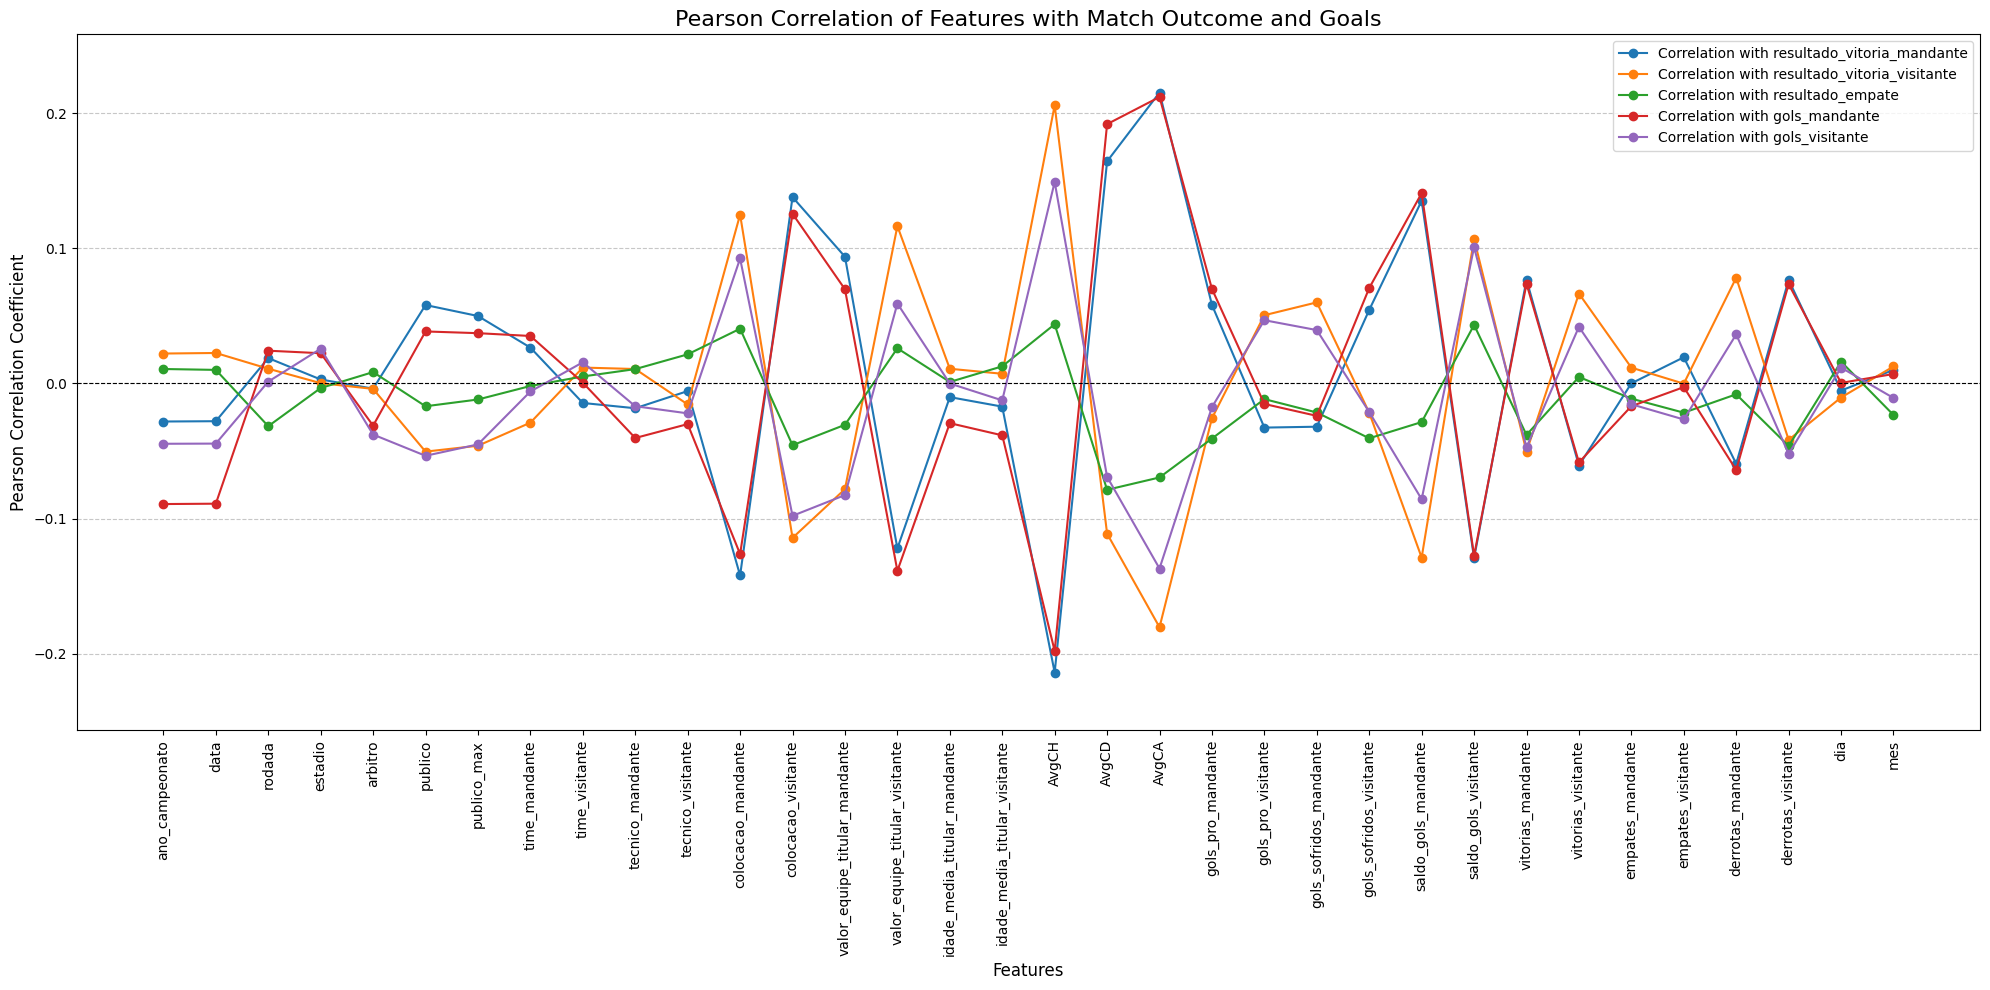

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the target columns
target_cols = ['resultado_vitoria_mandante', 'resultado_vitoria_visitante', 'resultado_empate', 'gols_mandante', 'gols_visitante']

# Calculate the correlation matrix
correlation_matrix = dataset.corr()

# Get the correlation of all features with the target columns
correlations = correlation_matrix[target_cols]

# Drop the target columns themselves from the list of features to plot
features_to_plot = correlations.drop(target_cols)

# Set up the matplotlib figure
plt.figure(figsize=(20, 10))

# Plot a line for each target variable
for target in target_cols:
    plt.plot(features_to_plot.index, features_to_plot[target], marker='o', linestyle='-', label=f'Correlation with {target}')

# Add titles and labels
plt.title('Pearson Correlation of Features with Match Outcome and Goals', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xticks(rotation=90)
plt.ylim(1.2*features_to_plot.min().min(), 1.2*features_to_plot.max().max()) # Correlation is always between -1 and 1

# Add horizontal line at y=0 for reference
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Add legend and grid
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


# Criando novas features a partir de outras (ex: média móvel de gols, média móvel de vitórias, etc)

In [23]:
# Inicializa as novas colunas com zero
new_cols = [
    'gols_sofridos_media_mandante', 'gols_sofridos_media_visitante',
    'gols_marcados_media_mandante', 'gols_marcados_media_visitante',
    'vitorias_confronto_mandante', 'vitorias_confronto_visitante', 'empates_confronto',
    'vitorias_seguidas_mandante', 'vitorias_seguidas_visitante',
    'colocacao_media_mandante', 'colocacao_media_visitante',
    'derrotas_seguidas_mandante', 'derrotas_seguidas_visitante'
]
for col in new_cols:
    dataset[col] = 0.0

# Dicionários para armazenar o histórico de confrontos e as sequências
confrontos_hist = {}  # (time1, time2) -> [vitorias_time1, vitorias_time2, empates]
sequencias = {}       # time -> {'vitorias_seguidas': int, 'derrotas_seguidas': int}
colocacao_hist = {}   # time -> [soma_colocacoes, num_jogos]

# Itera sobre cada temporada para calcular as novas features
for ano in sorted(dataset['ano_campeonato'].unique()):
    df_temporada = dataset[dataset['ano_campeonato'] == ano]
    
    # Reseta as sequências e histórico de colocação a cada temporada
    sequencias.clear()
    colocacao_hist.clear()
    
    for index, row in df_temporada.iterrows():
        # --- Médias de Gols (1 e 2) ---
        jogos_disputados_mandante = row['rodada'] - 1
        jogos_disputados_visitante = row['rodada'] - 1

        if jogos_disputados_mandante > 0:
            dataset.loc[index, 'gols_sofridos_media_mandante'] = row['gols_sofridos_mandante'] / jogos_disputados_mandante
            dataset.loc[index, 'gols_marcados_media_mandante'] = row['gols_pro_mandante'] / jogos_disputados_mandante
        
        if jogos_disputados_visitante > 0:
            dataset.loc[index, 'gols_sofridos_media_visitante'] = row['gols_sofridos_visitante'] / jogos_disputados_visitante
            dataset.loc[index, 'gols_marcados_media_visitante'] = row['gols_pro_visitante'] / jogos_disputados_visitante

        time_m = row['time_mandante']
        time_v = row['time_visitante']

        # --- Vitórias no Confronto (3) ---
        # Ordena os times para criar uma chave única para o confronto
        chave_confronto = tuple(sorted((time_m, time_v)))
        if chave_confronto not in confrontos_hist:
            confrontos_hist[chave_confronto] = [0, 0, 0]
        
        hist = confrontos_hist[chave_confronto]
        total_confrontos = sum(hist)
        if total_confrontos > 0:
            vitorias_m = hist[0] if time_m < time_v else hist[1]
            vitorias_v = hist[1] if time_m < time_v else hist[0]
            dataset.loc[index, 'vitorias_confronto_mandante'] = vitorias_m #/ total_confrontos
            dataset.loc[index, 'vitorias_confronto_visitante'] = vitorias_v #/ total_confrontos
            dataset.loc[index, 'empates_confronto'] = hist[2] #/ total_confrontos

        # --- Sequências de Vitórias/Derrotas (4 e 6) e Média de Colocação (5) ---
        for time, tipo in [(time_m, 'mandante'), (time_v, 'visitante')]:
            if time not in sequencias:
                sequencias[time] = {'vitorias_seguidas': 0, 'derrotas_seguidas': 0}
            if time not in colocacao_hist:
                colocacao_hist[time] = [0, 0]

            dataset.loc[index, f'vitorias_seguidas_{tipo}'] = sequencias[time]['vitorias_seguidas']
            dataset.loc[index, f'derrotas_seguidas_{tipo}'] = sequencias[time]['derrotas_seguidas']
            
            soma_col, num_jogos = colocacao_hist[time]
            if num_jogos > 0:
                dataset.loc[index, f'colocacao_media_{tipo}'] = soma_col / num_jogos
            else: # Primeira rodada
                col_colocacao = f'colocacao_{tipo}'
                dataset.loc[index, f'colocacao_media_{tipo}'] = dataset[col_colocacao].mean()

        # --- Atualiza os históricos após atribuir os valores para a partida atual ---
        # Atualiza histórico de confrontos
        if row['gols_mandante'] > row['gols_visitante']:
            if time_m < time_v: confrontos_hist[chave_confronto][0] += 1
            else: confrontos_hist[chave_confronto][1] += 1
        elif row['gols_visitante'] > row['gols_mandante']:
            if time_m < time_v: confrontos_hist[chave_confronto][1] += 1
            else: confrontos_hist[chave_confronto][0] += 1
        else:
            confrontos_hist[chave_confronto][2] += 1

        # Atualiza sequências e colocação para o time mandante
        if row['gols_mandante'] > row['gols_visitante']:
            sequencias[time_m]['vitorias_seguidas'] += 1
            sequencias[time_m]['derrotas_seguidas'] = 0
        elif row['gols_mandante'] < row['gols_visitante']:
            sequencias[time_m]['vitorias_seguidas'] = 0
            sequencias[time_m]['derrotas_seguidas'] += 1
        else:
            sequencias[time_m]['vitorias_seguidas'] = 0
            sequencias[time_m]['derrotas_seguidas'] = 0
        
        colocacao_hist[time_m][0] += row['colocacao_mandante']
        colocacao_hist[time_m][1] += 1

        # Atualiza sequências e colocação para o time visitante
        if row['gols_visitante'] > row['gols_mandante']:
            sequencias[time_v]['vitorias_seguidas'] += 1
            sequencias[time_v]['derrotas_seguidas'] = 0
        elif row['gols_visitante'] < row['gols_mandante']:
            sequencias[time_v]['vitorias_seguidas'] = 0
            sequencias[time_v]['derrotas_seguidas'] += 1
        else:
            sequencias[time_v]['vitorias_seguidas'] = 0
            sequencias[time_v]['derrotas_seguidas'] = 0
            
        colocacao_hist[time_v][0] += row['colocacao_visitante']
        colocacao_hist[time_v][1] += 1

dataset[new_cols].describe()

,gols_sofridos_media_mandante,gols_sofridos_media_visitante,gols_marcados_media_mandante,gols_marcados_media_visitante,vitorias_confronto_mandante,vitorias_confronto_visitante,empates_confronto,vitorias_seguidas_mandante,vitorias_seguidas_visitante,colocacao_media_mandante,colocacao_media_visitante,derrotas_seguidas_mandante,derrotas_seguidas_visitante
count,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000
mean,1.407393,1.380705,1.374224,1.408597,3.989081,4.100904,2.966491,0.552711,0.716679,10.945452,10.907498,0.719127,0.568053
std,0.855399,0.800008,0.767213,1.068533,4.178101,4.193878,3.174608,1.089192,1.157355,4.869729,4.874877,1.174900,1.147865
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,1.076923,1.047619,1.050000,1.076211,1.000000,1.000000,1.000000,0.000000,0.000000,7.138742,7.116013,0.000000,0.000000
50%,1.357143,1.333333,1.333333,1.333333,3.000000,3.000000,2.000000,0.000000,0.000000,10.998494,10.889966,0.000000,0.000000
75%,1.666667,1.656250,1.656250,1.675676,6.000000,6.000000,4.000000,1.000000,1.000000,14.857143,14.866667,1.000000,1.000000
max,45.000000,38.000000,36.000000,81.000000,23.000000,23.000000,20.000000,13.000000,14.000000,23.000000,24.000000,17.000000,16.000000


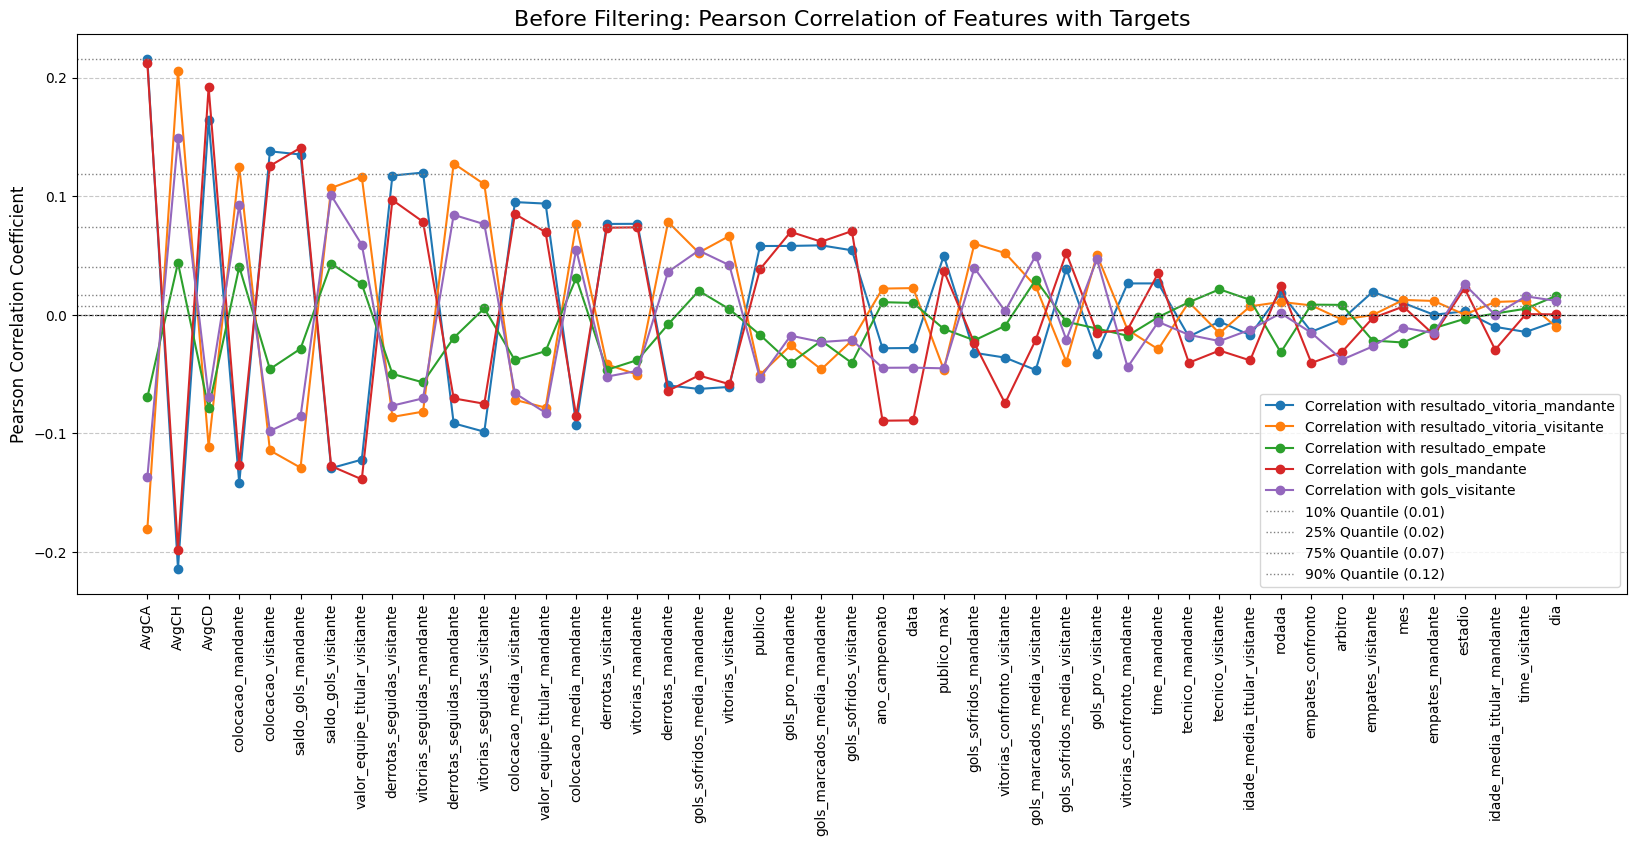

In [24]:
# Recalculate correlations to include the new features from the previous cell
correlation_matrix = dataset.corr()
correlations = correlation_matrix[target_cols]
features_to_plot = correlations.drop(target_cols)

# Plot correlations BEFORE removal
plt.figure(figsize=(20, 16))
plt.subplot(2, 1, 1)

# Sort features by the mean absolute correlation for better visualization
features_to_plot_sorted = features_to_plot.reindex(features_to_plot.abs().mean(axis=1).sort_values(ascending=False).index)

for target in target_cols:
    plt.plot(features_to_plot_sorted.index, features_to_plot_sorted[target], marker='o', linestyle='-', label=f'Correlation with {target}')

plt.title('Before Filtering: Pearson Correlation of Features with Targets', fontsize=16)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xticks(rotation=90)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Add quantile lines
quantiles = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]
for q in quantiles:
    quantile_value = features_to_plot_sorted.stack().abs().quantile(q)
    plt.axhline(y=quantile_value, color='grey', linestyle=':', linewidth=1, 
                label=f'{int(q*100)}% Quantile ({quantile_value:.2f})' if q in [0.1, 0.25, 0.75, 0.9] else None)


plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [25]:
# Define a threshold for low correlation
# A small value to remove only features with almost zero correlation with all targets
#correlation_threshold = 0.1

# Identify features to keep. A feature is kept if its absolute correlation with ANY target is above the threshold.
#features_to_keep = features_to_plot[features_to_plot.abs().max(axis=1) > correlation_threshold].index

# Create a new dataframe with only the selected features and the target columns
#dataset = dataset[features_to_keep.union(target_cols + ['ano_campeonato', 'data', 'rodada', "arbitro", "estadio", "tecnico_mandante", "tecnico_visitante", "time_mandante", "time_visitante"])]

#print("Original number of features:", len(features_to_plot))
#print("Number of features after filtering:", len(features_to_keep))
#removed_features = features_to_plot.index.difference(features_to_keep)
#print(removed_features.tolist())

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 52 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  10624 non-null  int64  
 1   data                            10624 non-null  float64
 2   rodada                          10624 non-null  int64  
 3   estadio                         10624 non-null  int64  
 4   arbitro                         10624 non-null  int64  
 5   publico                         10624 non-null  float64
 6   publico_max                     10624 non-null  float64
 7   time_mandante                   10624 non-null  int64  
 8   time_visitante                  10624 non-null  int64  
 9   tecnico_mandante                10624 non-null  int64  
 10  tecnico_visitante               10624 non-null  int64  
 11  colocacao_mandante              10624 non-null  float64
 12  colocacao_visitante             10624 non-n

In [26]:
dataset.to_csv('dataset_preprocessed.csv', index=False)